<h2> Notebook 2</h2>
<h3>Explotary Data Analysis (EDA)</h3>
<b>Objective:</b>
<p>The objective of this notebook is to explore the AI job market dataset through statistical analysis and data visualization. The analysis aims to uncover hiring trends, salary patterns, skill demand, company behavior, geographic distribution, and other insights that can support workforce planning and future job market forecasting.</p>

In [1]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load clean & engineered dataset
df = pd.read_csv("cleaned_engineered_jobdata.csv")
df["Date_Posted"] = pd.to_datetime(df["Date_Posted"])
df.head()

,Job_ID,Job_Title,Company,Company_Type,Industry,City,Location_Tier,Experience_Level,Job_Type,Work_Mode,...,Week,Day,Day_Name,Weekend_Posting,Salary_Category,Experience_Level_Encoded,Rating_Category,Applicant_Category,Hiring_Size,Skill_Count
0,IND2025000,Android Developer,Tech Mahindra,MNC,Information Technology,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,...,44,31,Friday,False,Premium,3,Average,High Competition,Small Hiring,3
1,IND2025001,QA Engineer,Dream11,Indian Unicorn,Information Technology,Lucknow,Tier 2,Senior (6-10 yrs),Full-Time,Hybrid,...,21,19,Monday,False,Premium,3,Average,High Competition,Small Hiring,5
2,IND2025002,Business Analyst,HAL,PSU/Govt,EdTech,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,...,34,21,Wednesday,False,High,3,Average,High Competition,Medium Hiring,3
3,IND2025003,Cybersecurity Analyst,Groww,Startup,Information Technology,Mumbai,Tier 1,Mid (3-6 yrs),Full-Time,Hybrid,...,12,18,Wednesday,False,High,2,Average,Medium Competition,Small Hiring,5
4,IND2025004,Python Developer,Oracle,MNC,EdTech,Remote,Remote,Junior (1-3 yrs),Full-Time,Remote,...,43,25,Friday,False,Medium,1,Average,Low Competition,Small Hiring,4


<h3>Business Question 1: How has AI changed overtime?</h3>

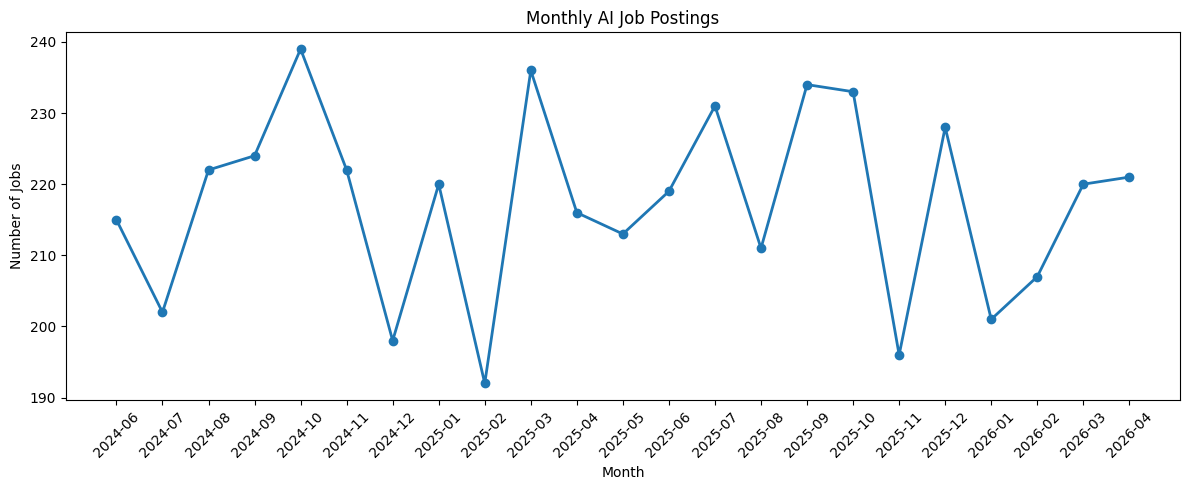

In [4]:
monthly_jobs = (df.groupby(df["Date_Posted"].dt.to_period("M")).size())
monthly_jobs.index = monthly_jobs.index.astype(str)
plt.figure(figsize=(12,5))
plt.plot(
    monthly_jobs.index,
    monthly_jobs.values,
    marker="o",
    linewidth=2)
plt.title("Monthly AI Job Postings")
plt.xlabel("Month")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<h3>Observations:</h3>
<p>The monthly hiring trend fluctuates between approximately 190 and 240 job postings without a clear long-term upward or downward trend.</p>


<h3>Business Question 2: Which AI job roles are most in demand?</h3>

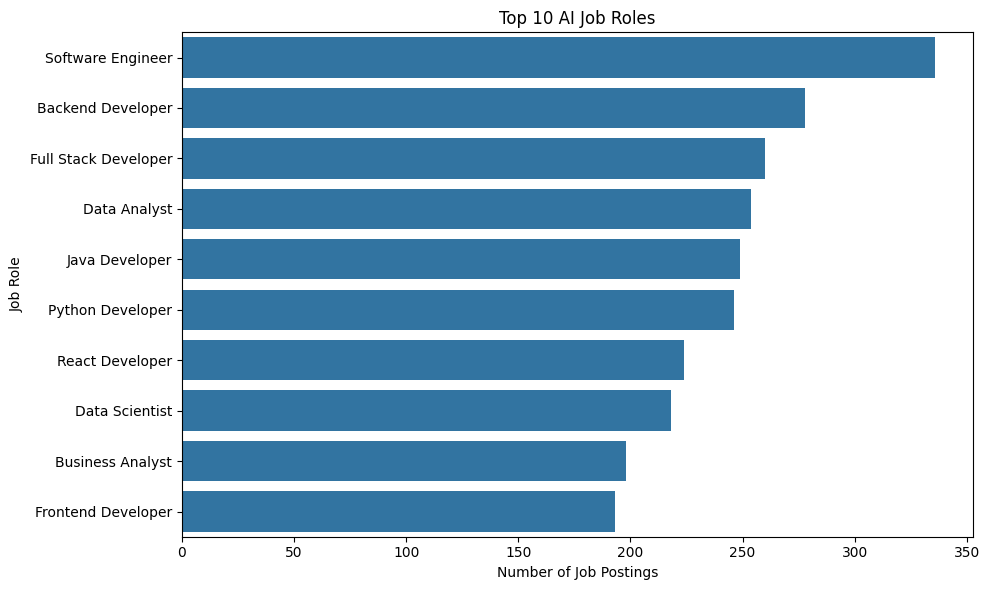

In [5]:
top_roles = (df["Job_Title"].value_counts().head(10))
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_roles.values,
    y=top_roles.index)
plt.title("Top 10 AI Job Roles")
plt.xlabel("Number of Job Postings")
plt.ylabel("Job Role")
plt.tight_layout()
plt.show()

<h3>Observations:</h3>
<p>Software Engineer, Backend Developer, Full Stack Developer, Data Analyst, and Java Developer appear at the top.</p>

<h3> Business Question 3: Which skills are most frequently required?</h3>

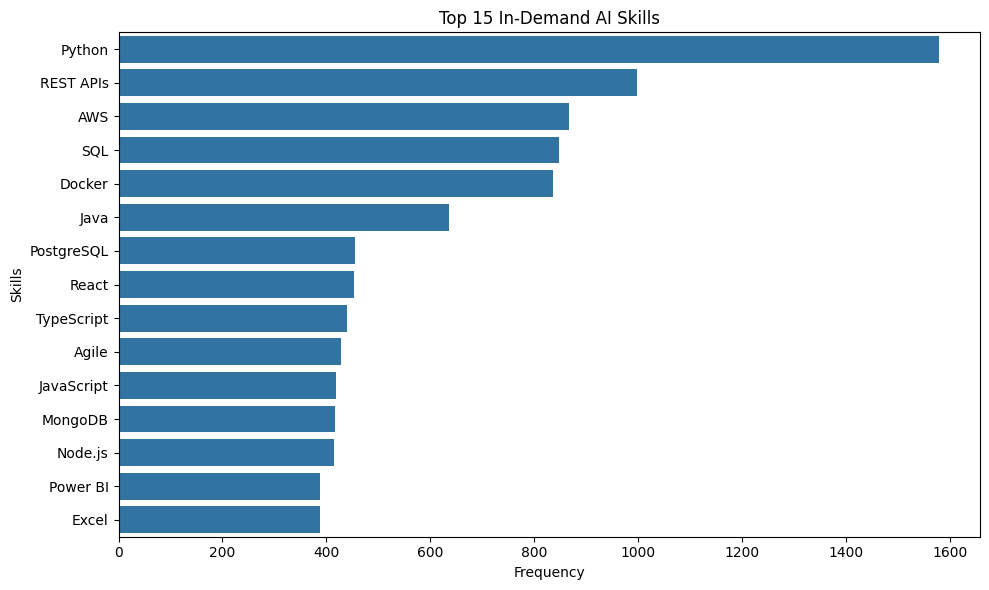

In [7]:
skills = (df["Skills_Required"].str.split(",").explode().str.strip())
top_skills = skills.value_counts().head(15)
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_skills.values,
    y=top_skills.index)
plt.title("Top 15 In-Demand AI Skills")
plt.xlabel("Frequency")
plt.ylabel("Skills")
plt.tight_layout()
plt.show()

<h3>Observations:</h3>
<p>Top skills include: Python, REST APIs, SQL, Docker, Java</p>

<h3>Business Question 4: Which cities have the highest AI hiring demand?</h3>

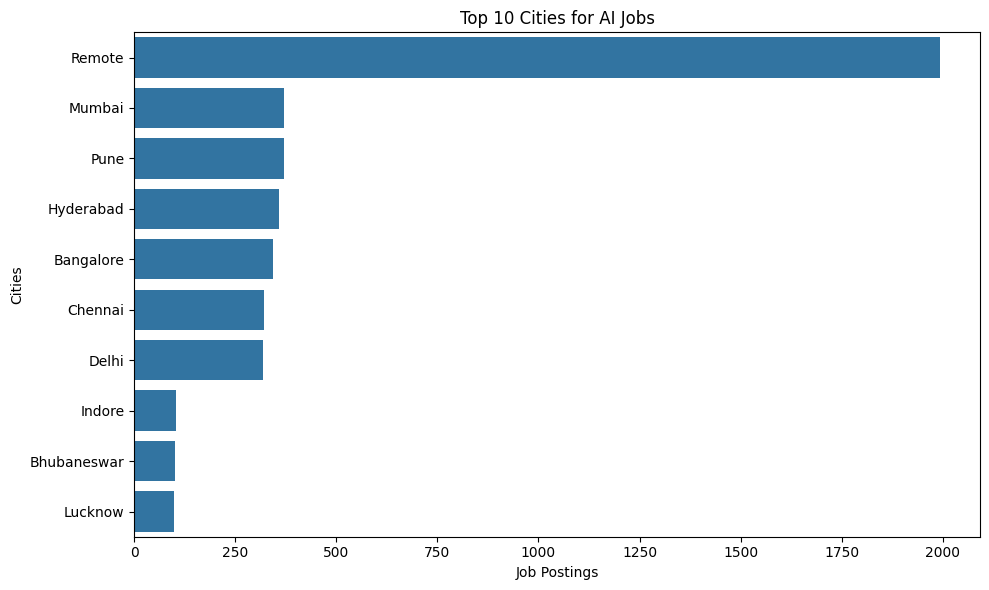

In [9]:
cities = df["City"].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(
    x=cities.values,
    y=cities.index)
plt.title("Top 10 Cities for AI Jobs")
plt.xlabel("Job Postings")
plt.ylabel("Cities")
plt.tight_layout()
plt.show()

<h3>Observations:</h3>
<p>Pune has significantly more postings than the other cities.</p>

<h3> Business Question 5: Which industries are hiring the most AI professionals? </h3>

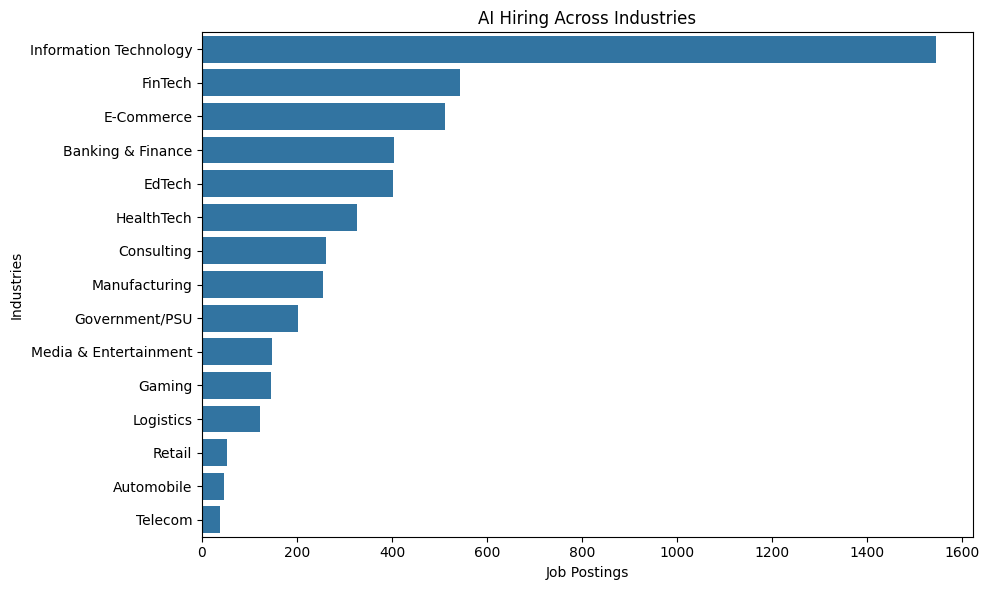

In [11]:
industry = df["Industry"].value_counts()
plt.figure(figsize=(10,6))
sns.barplot(
    x=industry.values,
    y=industry.index)
plt.title("AI Hiring Across Industries")
plt.xlabel("Job Postings")
plt.ylabel("Industries")
plt.tight_layout()
plt.show()

<h3>Observations:</h3>
<p>Information Technology clearly dominates.</p>

<h3>Business Question 6:How does salary vary across experience levels?</h3>

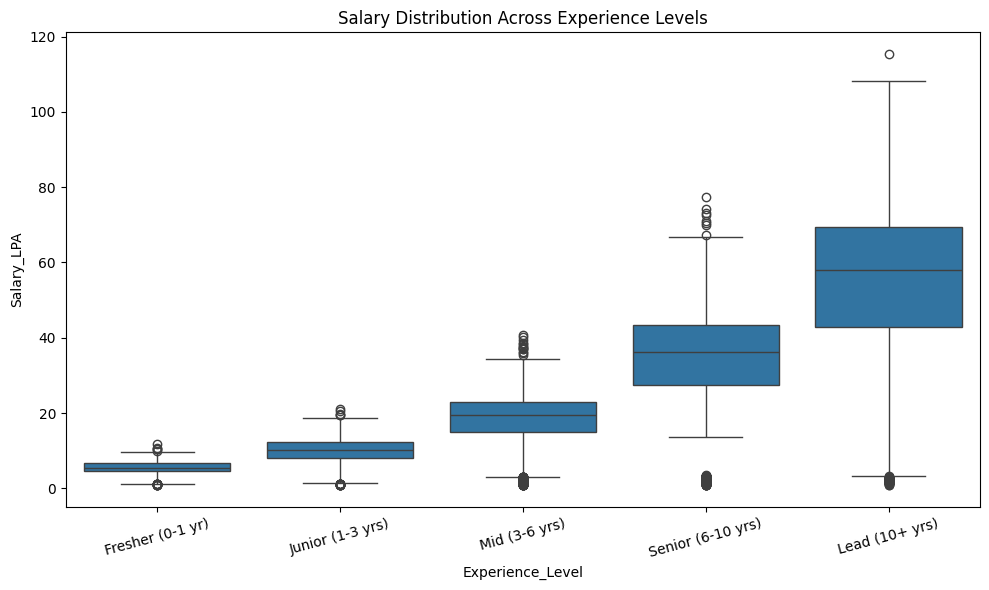

In [12]:
experience_order = [
    "Fresher (0-1 yr)",
    "Junior (1-3 yrs)",
    "Mid (3-6 yrs)",
    "Senior (6-10 yrs)",
    "Lead (10+ yrs)"]
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="Experience_Level",
    y="Salary_LPA",
    order=experience_order)
plt.title("Salary Distribution Across Experience Levels")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

<h3>Observations:</h3>
<p>Median salary increases consistently from Fresher to Lead</p>

<h3> Business Question 7:Which job roles offer the highest salaries?</h3>

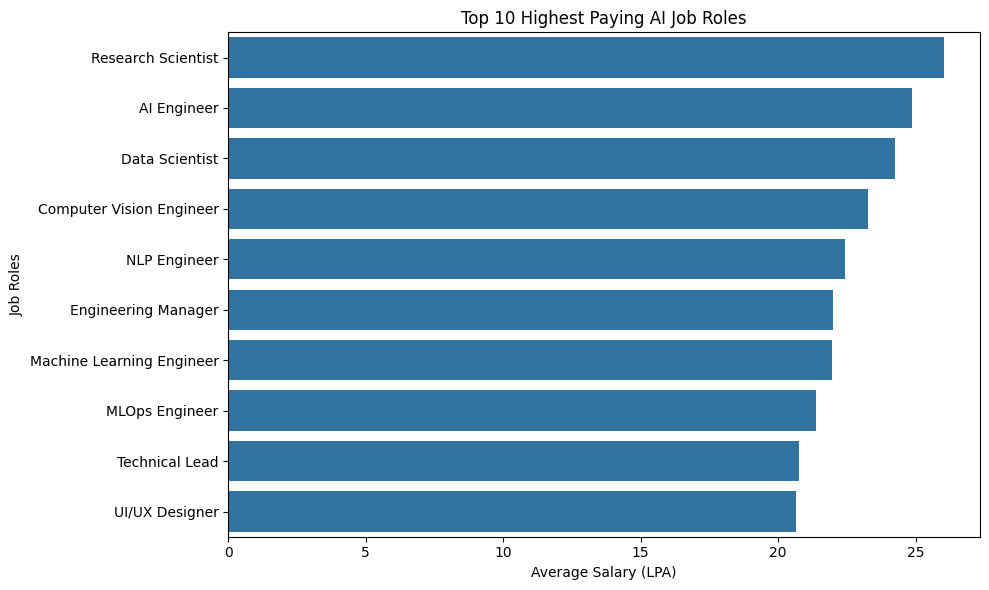

In [14]:
salary_role = (df.groupby("Job_Title")["Salary_LPA"].mean().sort_values(ascending=False).head(10))
plt.figure(figsize=(10,6))
sns.barplot(
    x=salary_role.values,
    y=salary_role.index)
plt.title("Top 10 Highest Paying AI Job Roles")
plt.xlabel("Average Salary (LPA)")
plt.ylabel("Job Roles")
plt.tight_layout()
plt.show()

<h3>Observations:</h3>
<p>Research Scientist and AI Engineer are among the highest-paying roles.</p>

<h3>Business Question 8: What is the distribution of work modes?</h3>

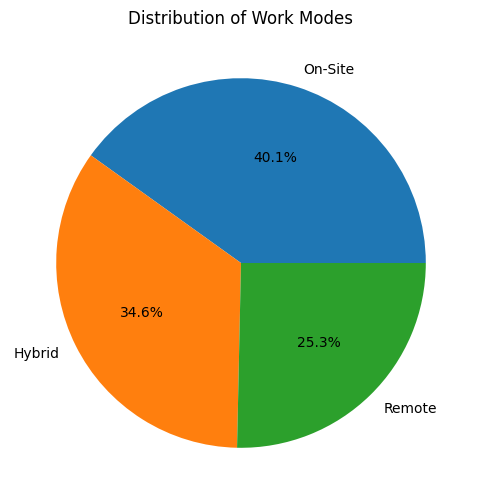

In [15]:
plt.figure(figsize=(6,6))
df["Work_Mode"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%")
plt.ylabel("")
plt.title("Distribution of Work Modes")
plt.show()

<h3> Observations:</h3>
<p>On-site is the largest category, followed by Hybrid and Remote.</p>

<h3> Business Question 9:Do higher salaries attract more applicants? </h3>

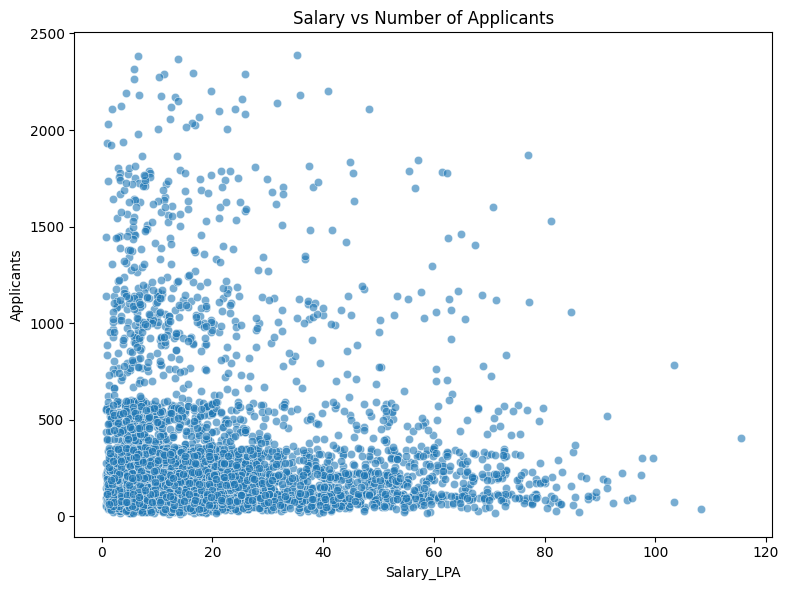

In [16]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Salary_LPA",
    y="Applicants",
    alpha=0.6)
plt.title("Salary vs Number of Applicants")
plt.tight_layout()
plt.show()

<h3>Observations:</h3>
<p>The scatter plot shows a weak relationship. Salary alone does not appear to determine applicant volume</p>

<h3> Business Question 10:Which variables are most correlated? </h3>

In [ ]:
numerical = [
    "Salary_LPA",
    "Applicants",
    "Company_Rating",
    "Openings",
    "Experience_Level_Encoded",
    "Skill_Count"]
plt.figure(figsize=(8,6))
sns.heatmap(df[numerical].corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

<h3> Observations:</h3>
<ul><li>Salary ↔ Experience ≈ 0.77</li>
    <li>Salary ↔ Applicants ≈ -0.02</li>
    <li>Salary ↔ Skill Count ≈ -0.02</li>
</ul>
<p>Experience level is the strongest predictor of salary in this dataset.</p>

<h3>Business Question 11: Quarterly Hiring Trend</h3>

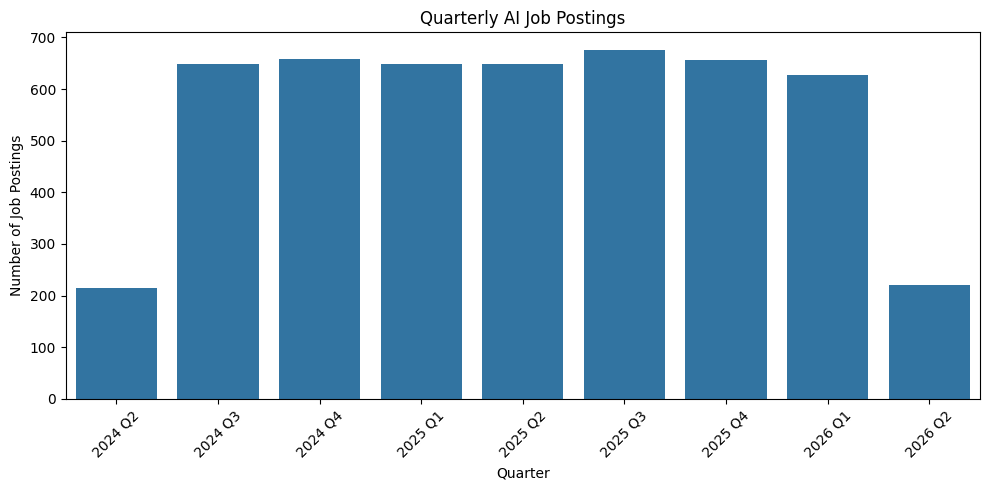

In [20]:
quarterly_jobs = (df.groupby(['Year', 'Quarter']).size().reset_index(name='Job_Postings'))
quarterly_jobs['Period'] = (quarterly_jobs['Year'].astype(str) +' Q' +quarterly_jobs['Quarter'].astype(str))
plt.figure(figsize=(10,5))
sns.barplot(
    data=quarterly_jobs,
    x='Period',
    y='Job_Postings')
plt.title('Quarterly AI Job Postings')
plt.xlabel('Quarter')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<h3>Observations:</h3>
<p>The lower job postings in 2024 Q2 and 2026 Q2 are due to partial-quarter data, while the remaining quarters show stable AI hiring with only minor fluctuations, indicating sustained market demand.</p>

<h3> Business Insights for all the Business Questions:</h3>
<ol>
<li><b>Monthly AI Hiring Trends: </b>AI hiring remained relatively stable across the study period, with moderate monthly fluctuations indicating consistent demand for AI professionals.</li>
<li><b>Quarterly AI Hiring Trend: </b>AI hiring remained relatively consistent across quarters, with only minor fluctuations, indicating stable recruitment activity throughout the study period.</li>
<li><b>Top AI Job Roles: </b>Software Engineer, Backend Developer, and Full Stack Developer emerged as the most in-demand roles, highlighting the strong demand for software engineering skills in AI projects.</li>
<li><b>Most In-Demand AI Skills: </b>Python was the most frequently required skill, followed by REST APIs, SQL, Docker, and Java, emphasizing the importance of programming, backend development, and cloud technologies.</li>
<li><b>Top Cities for AI Hiring: </b> remote work dominated AI job postings, followed by Mumbai, Hyderabad,pune, Bangalore, and Chennai, indicating that AI hiring is concentrated in major technology hubs.</li>
<li><b>AI Hiring Across Industries: </b>The Information Technology sector accounted for the highest number of AI job postings, with FinTech and E-Commerce also showing significant adoption of AI talent.</li>
<li><b>Salary Distribution Across Experience Levels: </b>Salaries increased consistently with experience level, demonstrating that organizations offer higher compensation for experienced AI professionals.</li>
<li><b>Highest Paying AI Job Roles: </b>Research Scientist, AI Engineer, and Data Scientist were among the highest-paying roles, reflecting the premium placed on specialized AI expertise.</li>
<li><b>Distribution of Work Modes: </b>On-site work emerged as the most common work arrangement, followed by Hybrid and remote roles, indicating a preference for flexible work environments.</li>
<li><b>Salary vs Number of Applicants: </b> The weak relationship between salary and applicant count suggests that compensation alone does not determine job attractiveness, with factors such as company reputation, location, and work mode also influencing applications</li>
<li><b>Correlation Analysis:</b> Experience level had the strongest positive correlation with salary (0.77), indicating that seniority is the most influential factor in determining compensation within the AI job market.</li>
</ol>